In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import re

# Cargar CSV completo
df = pd.read_csv("/content/drive/MyDrive/TFG/train.csv")

# Extraer patient_id desde la ruta
def get_patient_id(path):
    m = re.search(r"patient(\d+)", path)
    return int(m.group(1)) if m else None

df["patient_id"] = df["Path"].apply(get_patient_id)

# Subconjunto usado en el trabajo
df_batch2 = df[df["patient_id"] <= 21513].copy()

print("Total imágenes subconjunto:", len(df_batch2))
print("Pacientes únicos:", df_batch2["patient_id"].nunique())

Total imágenes subconjunto: 89484
Pacientes únicos: 21513


In [ ]:
# Distribución Frontal / Lateral
frontal_lateral = df_batch2["Frontal/Lateral"].value_counts()

print("Distribución Frontal / Lateral:")
print(frontal_lateral)

# Solo imágenes frontales
df_frontal = df_batch2[df_batch2["Frontal/Lateral"] == "Frontal"]

# Distribución AP / PA (solo en frontales)
ap_pa = df_frontal["AP/PA"].value_counts()

print("\nDistribución AP / PA (solo frontales):")
print(ap_pa)

Distribución Frontal / Lateral:
Frontal/Lateral
Frontal    70890
Lateral    18594
Name: count, dtype: int64

Distribución AP / PA (solo frontales):
AP/PA
AP    52639
PA    18244
LL        7
Name: count, dtype: int64


In [ ]:
cols_all = [c for c in df_batch2.columns if c not in ["Path", "patient_id", "Frontal/Lateral", "AP/PA"]]

datos_global = []

for c in cols_all:
    positivos = (df_batch2[c] == 1).sum()

    # solo mostramos patologías que aparecen
    if positivos > 0:
        datos_global.append({
            "Patología": c,
            "Casos positivos": positivos
        })

tabla_todas = pd.DataFrame(datos_global).sort_values(by="Casos positivos", ascending=False)
tabla_todas

,Patología,Casos positivos
13,Support Devices,42170
3,Lung Opacity,39451
10,Pleural Effusion,32397
5,Edema,18185
8,Atelectasis,12451
2,Cardiomegaly,11201
0,No Finding,10124
9,Pneumothorax,8092
6,Consolidation,5852
1,Enlarged Cardiomediastinum,4335


In [ ]:
cols = [
    "No Finding",
    "Pneumothorax",
    "Edema",
    "Pleural Effusion",
    "Enlarged Cardiomediastinum"
]

for c in cols:
    print(c, (df_frontal[c] == 1).sum())

No Finding 6939
Pneumothorax 7032
Edema 16896
Pleural Effusion 27169
Enlarged Cardiomediastinum 3431


In [ ]:
tabla_estructura = pd.DataFrame({
    "Tipo": ["Total", "Frontal", "Lateral", "AP", "PA", "LL"],
    "Cantidad": [
        len(df_batch2),
        frontal_lateral["Frontal"],
        frontal_lateral["Lateral"],
        ap_pa.get("AP", 0),
        ap_pa.get("PA", 0),
        ap_pa.get("LL", 0)
    ]
})

tabla_estructura

,Tipo,Cantidad
0,Total,89484
1,Frontal,70890
2,Lateral,18594
3,AP,52639
4,PA,18244
5,LL,7


In [ ]:
# Subconjunto solo PA
df_pa = df_batch2[
    (df_batch2["Frontal/Lateral"] == "Frontal") &
    (df_batch2["AP/PA"] == "PA")
].copy()

print("Total imágenes PA:", len(df_pa))

# Patologías de interés
cols = [
    "No Finding",
    "Pneumothorax",
    "Edema",
    "Pleural Effusion",
    "Enlarged Cardiomediastinum"
]

for c in cols:
    print(c, (df_pa[c] == 1).sum())

Total imágenes PA: 18244
No Finding 3350
Pneumothorax 1132
Edema 1034
Pleural Effusion 4980
Enlarged Cardiomediastinum 877


In [ ]:
datos_patologias_pa = []

for c in cols:
    datos_patologias_pa.append({
        "Clase": c,
        "Cantidad": (df_pa[c] == 1).sum()
    })

tabla_patologias_pa = pd.DataFrame(datos_patologias_pa)
tabla_patologias_pa

,Clase,Cantidad
0,No Finding,3350
1,Pneumothorax,1132
2,Edema,1034
3,Pleural Effusion,4980
4,Enlarged Cardiomediastinum,877


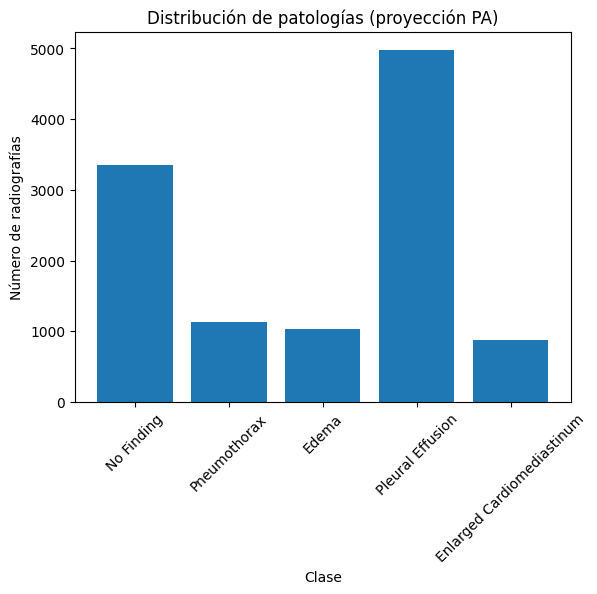

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(tabla_patologias_pa["Clase"], tabla_patologias_pa["Cantidad"])
plt.xticks(rotation=45)
plt.title("Distribución de patologías (proyección PA)")
plt.xlabel("Clase")
plt.ylabel("Número de radiografías")
plt.show()

In [ ]:
datos_uncertain = []

for c in cols:
    datos_uncertain.append({
        "Clase": c,
        "Cantidad -1": (df_pa[c] == -1).sum()
    })

tabla_uncertain = pd.DataFrame(datos_uncertain)
tabla_uncertain

,Clase,Cantidad -1
0,No Finding,0
1,Pneumothorax,241
2,Edema,517
3,Pleural Effusion,1115
4,Enlarged Cardiomediastinum,1187


In [ ]:
datos_estado = []

for c in cols:
    datos_estado.append({
        "Clase": c,
        "Presente (1)": (df_pa[c] == 1).sum(),
        "Ausente (0)": (df_pa[c] == 0).sum(),
        "Incierto (-1)": (df_pa[c] == -1).sum()
    })

tabla_estado = pd.DataFrame(datos_estado)
tabla_estado

,Clase,Presente (1),Ausente (0),Incierto (-1)
0,No Finding,3350,0,0
1,Pneumothorax,1132,5091,241
2,Edema,1034,2719,517
3,Pleural Effusion,4980,5972,1115
4,Enlarged Cardiomediastinum,877,3781,1187


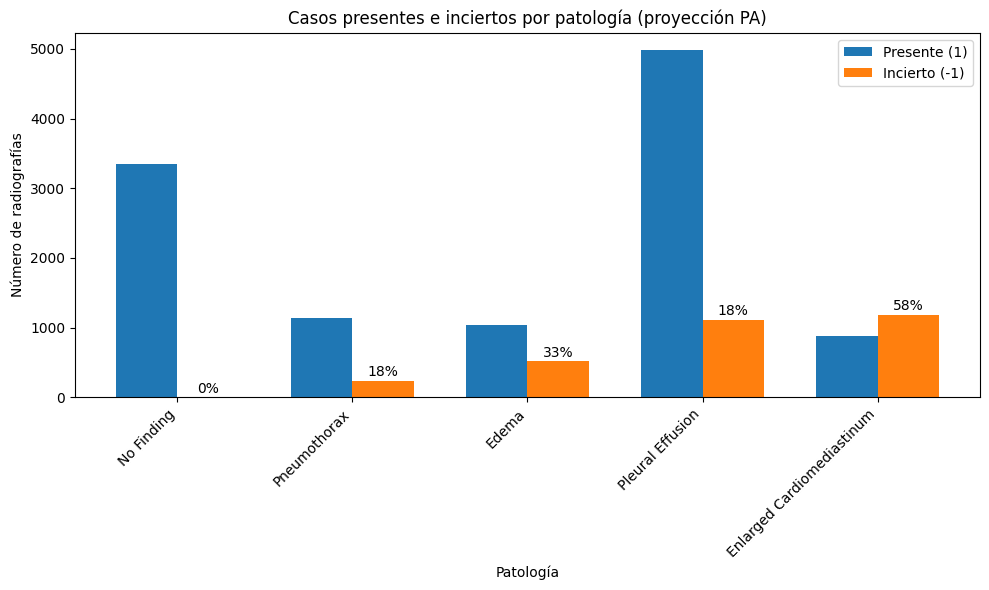

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

datos_estado = []

for c in cols:
    presentes = (df_pa[c] == 1).sum()
    inciertos = (df_pa[c] == -1).sum()
    total_relevante = presentes + inciertos
    pct_incierto = round((inciertos / total_relevante) * 100) if total_relevante > 0 else 0

    datos_estado.append({
        "Clase": c,
        "Presente": presentes,
        "Incierto": inciertos,
        "Pct_Incierto": pct_incierto
    })

df_estado = pd.DataFrame(datos_estado)

x = np.arange(len(df_estado))
width = 0.35

plt.figure(figsize=(10,6))
bars_presente = plt.bar(x - width/2, df_estado["Presente"], width, label="Presente (1)")
bars_incierto = plt.bar(x + width/2, df_estado["Incierto"], width, label="Incierto (-1)")

plt.xticks(x, df_estado["Clase"], rotation=45, ha="right")
plt.ylabel("Número de radiografías")
plt.xlabel("Patología")
plt.title("Casos presentes e inciertos por patología (proyección PA)")
plt.legend()

# Añadir porcentaje encima de cada barra de incierto
for bar, pct in zip(bars_incierto, df_estado["Pct_Incierto"]):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + max(df_estado["Incierto"]) * 0.02,
        f"{pct}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()